### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)

### Load the datasets

In [2]:
BASE = Path("../data/clean")

DAILY_PATH    = BASE / "daily_adjusted" / "ALL_daily_adjusted_clean.parquet"
INCOME_PATH   = BASE / "fundamentals" / "ALL_income_statement_clean.parquet"
BALANCE_PATH  = BASE / "fundamentals" / "ALL_balance_sheet_clean.parquet"
CASHFLOW_PATH = BASE / "fundamentals" / "ALL_cash_flow_clean.parquet"
OVERVIEW_PATH = BASE / "fundamentals" / "ALL_overview_clean.csv"
OPTIONS_PATH  = BASE / "options" / "ALL_options_clean.parquet"

print(DAILY_PATH)
print(INCOME_PATH)
print(BALANCE_PATH)
print(CASHFLOW_PATH)
print(OVERVIEW_PATH)
print(OPTIONS_PATH)

../data/clean/daily_adjusted/ALL_daily_adjusted_clean.parquet
../data/clean/fundamentals/ALL_income_statement_clean.parquet
../data/clean/fundamentals/ALL_balance_sheet_clean.parquet
../data/clean/fundamentals/ALL_cash_flow_clean.parquet
../data/clean/fundamentals/ALL_overview_clean.csv
../data/clean/options/ALL_options_clean.parquet


In [3]:
# Load the datasets
daily = pd.read_parquet(DAILY_PATH)
income = pd.read_parquet(INCOME_PATH)
balance = pd.read_parquet(BALANCE_PATH)
cashflow = pd.read_parquet(CASHFLOW_PATH)
overview = pd.read_csv(OVERVIEW_PATH)
options = pd.read_parquet(OPTIONS_PATH)

print("daily:", daily.shape)
print("income:", income.shape)
print("balance:", balance.shape)
print("cashflow:", cashflow.shape)
print("overview:", overview.shape)
print("options:", options.shape)

daily: (41258, 10)
income: (736, 22)
balance: (729, 33)
cashflow: (731, 17)
overview: (10, 55)
options: (2127108, 20)


In [4]:
# Parse date columns
daily["date"] = pd.to_datetime(daily["date"])

income["fiscalDateEnding"] = pd.to_datetime(income["fiscalDateEnding"])
balance["fiscalDateEnding"] = pd.to_datetime(balance["fiscalDateEnding"])
cashflow["fiscalDateEnding"] = pd.to_datetime(cashflow["fiscalDateEnding"])

print("Dates parsed.")

Dates parsed.


In [5]:
income.head()

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,netInterestIncome,interestIncome,interestExpense,otherNonOperatingIncome,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,ebit,ebitda,netIncome
0,AAPL,2005-12-31,USD,1564000000.0000,5749000000.0000,4185000000.0000,4185000000.0000,750000000,632000000.0000,182000000.0000,814000000,348000000.0000,1358000000.0000,81000000.0000,60000000.0000,52000000.0000,831000000,266000000.0000,0.0000,750000000.0000,802000000.0000,565000000
1,AAPL,2006-03-31,USD,1297000000.0000,4359000000.0000,3062000000.0000,3062000000.0000,529000000,592000000.0000,176000000.0000,768000000,348000000.0000,1358000000.0000,76000000.0000,60000000.0000,50000000.0000,605000000,195000000.0000,0.0000,529000000.0000,579000000.0000,410000000
2,AAPL,2006-06-30,USD,1325000000.0000,4370000000.0000,3045000000.0000,3045000000.0000,566000000,584000000.0000,175000000.0000,759000000,348000000.0000,1358000000.0000,0.0000,60000000.0000,57000000.0000,661000000,189000000.0000,0.0000,566000000.0000,623000000.0000,472000000
3,AAPL,2006-09-30,USD,1412000000.0000,4370000000.0000,3425000000.0000,3425000000.0000,608000000,584000000.0000,179000000.0000,804000000,348000000.0000,1358000000.0000,252000000.0000,60000000.0000,66000000.0000,721000000,179000000.0000,0.0000,661000000.0000,718000000.0000,542000000
4,AAPL,2006-12-31,USD,2220000000.0000,7115000000.0000,4895000000.0000,4895000000.0000,1322000000,714000000.0000,184000000.0000,898000000,348000000.0000,1358000000.0000,126000000.0000,60000000.0000,74000000.0000,1448000000,444000000.0000,0.0000,1322000000.0000,1396000000.0000,1004000000


In [6]:
# Inspect columns before merging
print("DAILY COLUMNS")
print(daily.columns.tolist())

print("\nINCOME COLUMNS")
print(income.columns.tolist())

print("\nBALANCE COLUMNS")
print(balance.columns.tolist())

print("\nCASHFLOW COLUMNS")
print(cashflow.columns.tolist())

print("\nOVERVIEW COLUMNS")
print(overview.columns.tolist())

DAILY COLUMNS
['date', 'symbol', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividend', 'split_coeff']

INCOME COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'grossProfit', 'totalRevenue', 'costOfRevenue', 'costofGoodsAndServicesSold', 'operatingIncome', 'sellingGeneralAndAdministrative', 'researchAndDevelopment', 'operatingExpenses', 'netInterestIncome', 'interestIncome', 'interestExpense', 'otherNonOperatingIncome', 'depreciationAndAmortization', 'incomeBeforeTax', 'incomeTaxExpense', 'netIncomeFromContinuingOperations', 'ebit', 'ebitda', 'netIncome']

BALANCE COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'cashAndShortTermInvestments', 'inventory', 'currentNetReceivables', 'totalNonCurrentAssets', 'propertyPlantEquipment', 'intangibleAssets', 'intangibleAssetsExcludingGoodwill', 'goodwill', 'longTermInvestments', 'shortTermInvestments', 'otherCurrentAssets', 'totalLiabil

### Keeping only important columns from the datasets

In [7]:
# From daily adjustments
daily_keep = [
    "date", "symbol", "open", "high", "low", "close",
    "adj_close", "volume", "dividend", "split_coeff"
]

daily = daily[daily_keep].copy()
daily.head()

,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff
0,2013-10-17,ADMA,7.0000,8.9100,7.0000,8.5500,8.5500,145708,0.0000,1.0000
1,2013-10-18,ADMA,8.5400,8.5500,8.5000,8.5300,8.5300,28400,0.0000,1.0000
2,2013-10-21,ADMA,8.5000,8.5000,8.0500,8.4000,8.4000,24500,0.0000,1.0000
3,2013-10-22,ADMA,8.4000,8.5000,8.4000,8.4500,8.4500,5100,0.0000,1.0000
4,2013-10-23,ADMA,8.4500,8.5000,8.4500,8.4900,8.4900,16900,0.0000,1.0000


In [8]:
# Income statement
income_keep = [
    "symbol", "fiscalDateEnding",
    "totalRevenue", "grossProfit", "operatingIncome",
    "operatingExpenses", "ebit", "ebitda", "netIncome"
]

income = income[[c for c in income_keep if c in income.columns]].copy()
income.head()

,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome
0,AAPL,2005-12-31,5749000000.0000,1564000000.0000,750000000,814000000,750000000.0000,802000000.0000,565000000
1,AAPL,2006-03-31,4359000000.0000,1297000000.0000,529000000,768000000,529000000.0000,579000000.0000,410000000
2,AAPL,2006-06-30,4370000000.0000,1325000000.0000,566000000,759000000,566000000.0000,623000000.0000,472000000
3,AAPL,2006-09-30,4370000000.0000,1412000000.0000,608000000,804000000,661000000.0000,718000000.0000,542000000
4,AAPL,2006-12-31,7115000000.0000,2220000000.0000,1322000000,898000000,1322000000.0000,1396000000.0000,1004000000


In [9]:
# Balance sheet
balance_keep = [
    "symbol", "fiscalDateEnding",
    "totalAssets", "totalCurrentAssets",
    "cashAndCashEquivalentsAtCarryingValue",
    "totalLiabilities", "totalCurrentLiabilities",
    "longTermDebt", "totalShareholderEquity",
    "commonStockSharesOutstanding"
]

balance = balance[[c for c in balance_keep if c in balance.columns]].copy()
balance.head()

,symbol,fiscalDateEnding,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding
0,AAPL,2005-12-31,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000
1,AAPL,2006-03-31,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000
2,AAPL,2006-06-30,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000
3,AAPL,2006-09-30,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000
4,AAPL,2006-12-31,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000


In [10]:
# Cash flow
cashflow_keep = [
    "symbol", "fiscalDateEnding",
    "operatingCashflow", "capitalExpenditures",
    "cashflowFromInvestment", "cashflowFromFinancing",
    "dividendPayout", "netIncome"
]

cashflow = cashflow[[c for c in cashflow_keep if c in cashflow.columns]].copy()
cashflow.head()

,symbol,fiscalDateEnding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,AAPL,2005-12-31,283000000.0000,82000000,93000000.0000,283000000.0000,2488000000.0000,565000000
1,AAPL,2006-03-31,-125000000.0000,193000000,2462000000.0000,-141000000.0000,2488000000.0000,410000000
2,AAPL,2006-06-30,1007000000.0000,237000000,3086000000.0000,129000000.0000,2488000000.0000,472000000
3,AAPL,2006-09-30,1055000000.0000,145000000,357000000.0000,53000000.0000,2488000000.0000,542000000
4,AAPL,2006-12-31,1813000000.0000,257000000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000


In [11]:
#Overview
overview_keep = [
    "Symbol",
    "MarketCapitalization",
    "PERatio",
    "BookValue",
    "DividendYield",
    "EPS",
    "RevenueTTM",
    "ProfitMargin",
    "OperatingMarginTTM",
    "ReturnOnAssetsTTM",
    "ReturnOnEquityTTM",
    "Beta",
    "52WeekHigh",
    "52WeekLow",
    "50DayMovingAverage",
    "200DayMovingAverage",
    "SharesOutstanding"
]

overview = overview[[c for c in overview_keep if c in overview.columns]].copy()
overview = overview.rename(columns={"Symbol": "symbol"})
overview.head(10)

,symbol,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,ADMA,3608111000,25.2500,2.0070,0.0000,0.6000,510173000,0.2880,0.4510,0.2150,0.3560,0.5930,25.6700,13.7600,16.7500,17.2300,238159000
1,NTRA,26624215000,29.0000,12.2600,0.0000,-1.5200,2306113000,-0.0903,-0.0342,-0.0954,-0.1430,1.7020,256.3600,125.3800,220.9800,190.1600,141731000
2,AXON,39891718000,333.0100,40.4300,0.0000,1.4900,2779536000,0.0449,-0.0306,-0.0032,0.0448,1.5240,885.9200,396.4100,533.9200,662.4400,80398000
3,SHAK,3710833000,79.7400,13.0500,0.0000,1.0900,1445306000,0.0316,0.0513,0.0236,0.0949,1.7660,144.6500,72.9300,92.6700,102.9100,40257700
4,AAPL,3676245066000,31.6600,6.0000,0.0040,7.9000,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,263.1700,245.3300,14681140000
5,MSFT,2939877065000,24.7500,52.6200,0.0087,15.9800,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,431.2000,483.5900,7425629000
6,NVDA,4380976218000,36.7900,6.4700,0.0002,4.9000,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.6100,177.1700,24300000000
7,AMZN,2229321073000,29.0000,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,223.8000,224.6900,10734921000
8,GOOG,3646761730000,27.8600,34.3500,0.0027,10.8200,402835997000,0.3280,0.3160,0.1540,0.3570,1.1120,349.9000,142.1700,319.4700,256.4900,5438000000
9,META,1552413491000,26.1000,85.8700,0.0033,23.5100,200965997000,0.3010,0.4130,0.1620,0.3020,1.2790,795.0600,478.7200,655.3100,691.7900,2187178000


In [12]:
# Convert numeric columns properly
def convert_numeric(df, exclude_cols):
    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

income = convert_numeric(income, ["symbol", "fiscalDateEnding"])
balance = convert_numeric(balance, ["symbol", "fiscalDateEnding"])
cashflow = convert_numeric(cashflow, ["symbol", "fiscalDateEnding"])
overview = convert_numeric(overview, ["symbol"])

print("Numeric conversion done.")

Numeric conversion done.


### Merge income + balance + cashflow into one quarterly fundamentals table


In [13]:
fundamentals = income.merge(
    balance,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

fundamentals = fundamentals.merge(
    cashflow,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

print("fundamentals shape:", fundamentals.shape)
fundamentals.head()

fundamentals shape: (736, 23)


,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome_x,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome_y
0,AAPL,2005-12-31,5749000000.0000,1564000000.0000,750000000,814000000,750000000.0000,802000000.0000,565000000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000
1,AAPL,2006-03-31,4359000000.0000,1297000000.0000,529000000,768000000,529000000.0000,579000000.0000,410000000,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000,-125000000.0000,193000000.0000,2462000000.0000,-141000000.0000,2488000000.0000,410000000.0000
2,AAPL,2006-06-30,4370000000.0000,1325000000.0000,566000000,759000000,566000000.0000,623000000.0000,472000000,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000,1007000000.0000,237000000.0000,3086000000.0000,129000000.0000,2488000000.0000,472000000.0000
3,AAPL,2006-09-30,4370000000.0000,1412000000.0000,608000000,804000000,661000000.0000,718000000.0000,542000000,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000,1055000000.0000,145000000.0000,357000000.0000,53000000.0000,2488000000.0000,542000000.0000
4,AAPL,2006-12-31,7115000000.0000,2220000000.0000,1322000000,898000000,1322000000.0000,1396000000.0000,1004000000,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000,1813000000.0000,257000000.0000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000.0000


In [14]:
# check for duplicates
print(fundamentals.columns.tolist())

['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'operatingExpenses', 'ebit', 'ebitda', 'netIncome_x', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'totalLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'totalShareholderEquity', 'commonStockSharesOutstanding', 'operatingCashflow', 'capitalExpenditures', 'cashflowFromInvestment', 'cashflowFromFinancing', 'dividendPayout', 'netIncome_y']


In [15]:
dup_cols = [c for c in fundamentals.columns if c.endswith("_x") or c.endswith("_y")]
print(dup_cols)

['netIncome_x', 'netIncome_y']


In [16]:
if "netIncome_x" in fundamentals.columns and "netIncome_y" in fundamentals.columns:
    fundamentals["netIncome"] = fundamentals["netIncome_x"].fillna(fundamentals["netIncome_y"])
    fundamentals = fundamentals.drop(columns=["netIncome_x", "netIncome_y"])

In [17]:
# Sort data before merge asof
daily = daily.sort_values(["symbol", "date"]).reset_index(drop=True)
fundamentals = fundamentals.sort_values(["symbol", "fiscalDateEnding"]).reset_index(drop=True)


In [18]:
#Merge fundamentals onto daily prices
# date columns are datetime
daily["date"] = pd.to_datetime(daily["date"])
fundamentals["fiscalDateEnding"] = pd.to_datetime(fundamentals["fiscalDateEnding"])

# sort by the asof key first, then by symbol
daily_sorted = daily.sort_values(["date", "symbol"]).reset_index(drop=True)
fundamentals_sorted = fundamentals.sort_values(["fiscalDateEnding", "symbol"]).reset_index(drop=True)

master = pd.merge_asof(
    daily_sorted,
    fundamentals_sorted,
    left_on="date",
    right_on="fiscalDateEnding",
    by="symbol",
    direction="backward"
)

print("master after fundamentals merge:", master.shape)
master.head()

master after fundamentals merge: (41258, 31)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,2005-01-03,AAPL,64.7800,65.1100,62.6000,63.2900,0.9482,12357000,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-03,AMZN,44.9500,45.4400,44.2100,44.5200,2.2260,10446500,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-03,AXON,32.3500,32.4900,28.8800,29.9800,29.9800,13549500,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-01-03,MSFT,26.8000,26.9500,26.6490,26.7400,18.3812,65002900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-01-03,NVDA,24.3800,24.7200,23.4800,23.5800,0.1802,8889300,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# check duplicate rows in master
print(
    "Duplicate symbol + date rows:",
    master.duplicated(subset=["symbol", "date"]).sum()
)

Duplicate symbol + date rows: 0


In [20]:
# Merge overview into master
master = master.merge(
    overview,
    on="symbol",
    how="left"
)

print("master after overview merge:", master.shape)
master.head()

master after overview merge: (41258, 47)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,2005-01-03,AAPL,64.7800,65.1100,62.6000,63.2900,0.9482,12357000,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3676245066000,31.6600,6.0000,0.0040,7.9000,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,263.1700,245.3300,14681140000
1,2005-01-03,AMZN,44.9500,45.4400,44.2100,44.5200,2.2260,10446500,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2229321073000,29.0000,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,223.8000,224.6900,10734921000
2,2005-01-03,AXON,32.3500,32.4900,28.8800,29.9800,29.9800,13549500,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39891718000,333.0100,40.4300,0.0000,1.4900,2779536000,0.0449,-0.0306,-0.0032,0.0448,1.5240,885.9200,396.4100,533.9200,662.4400,80398000
3,2005-01-03,MSFT,26.8000,26.9500,26.6490,26.7400,18.3812,65002900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2939877065000,24.7500,52.6200,0.0087,15.9800,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,431.2000,483.5900,7425629000
4,2005-01-03,NVDA,24.3800,24.7200,23.4800,23.5800,0.1802,8889300,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4380976218000,36.7900,6.4700,0.0002,4.9000,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.6100,177.1700,24300000000


In [21]:
print("master shape:", master.shape)
print("Duplicate symbol + date rows:", master.duplicated(subset=["symbol", "date"]).sum())

null_summary = master.isnull().sum().sort_values(ascending=False)
print(null_summary[null_summary > 0].head(20))

master shape: (41258, 47)
Duplicate symbol + date rows: 0
totalShareholderEquity                   1279
ebit                                     1279
netIncome                                1279
dividendPayout                           1279
cashflowFromFinancing                    1279
cashflowFromInvestment                   1279
capitalExpenditures                      1279
operatingCashflow                        1279
commonStockSharesOutstanding             1279
longTermDebt                             1279
totalCurrentLiabilities                  1279
totalLiabilities                         1279
cashAndCashEquivalentsAtCarryingValue    1279
totalCurrentAssets                       1279
totalAssets                              1279
ebitda                                   1279
operatingIncome                          1279
grossProfit                              1279
totalRevenue                             1279
fiscalDateEnding                         1279
dtype: int64


In [22]:
#check missing nulls after merge
# Null summary
null_summary = master.isnull().sum().sort_values(ascending=False)
null_summary = null_summary[null_summary > 0]

print("Columns with nulls:")
print(null_summary)

Columns with nulls:
totalShareholderEquity                   1279
ebit                                     1279
netIncome                                1279
dividendPayout                           1279
cashflowFromFinancing                    1279
cashflowFromInvestment                   1279
capitalExpenditures                      1279
operatingCashflow                        1279
commonStockSharesOutstanding             1279
longTermDebt                             1279
totalCurrentLiabilities                  1279
totalLiabilities                         1279
cashAndCashEquivalentsAtCarryingValue    1279
totalCurrentAssets                       1279
totalAssets                              1279
ebitda                                   1279
operatingIncome                          1279
grossProfit                              1279
totalRevenue                             1279
fiscalDateEnding                         1279
operatingExpenses                        1279
dtype: int64


In [23]:
null_pct = (master.isnull().sum() / len(master) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

null_report = pd.DataFrame({
    "null_count": master.isnull().sum(),
    "null_pct": (master.isnull().sum() / len(master) * 100)
}).sort_values("null_pct", ascending=False)

null_report = null_report[null_report["null_count"] > 0]
null_report.head(30)

,null_count,null_pct
totalShareholderEquity,1279,3.1000
ebit,1279,3.1000
netIncome,1279,3.1000
dividendPayout,1279,3.1000
cashflowFromFinancing,1279,3.1000
cashflowFromInvestment,1279,3.1000
capitalExpenditures,1279,3.1000
operatingCashflow,1279,3.1000
commonStockSharesOutstanding,1279,3.1000
longTermDebt,1279,3.1000


In [24]:
#Basic dataset sanity checks
print("Master shape:", master.shape)
print("Unique tickers:", master["symbol"].nunique())
print("Date range:", master["date"].min(), "to", master["date"].max())
print("Duplicate symbol-date rows:", master.duplicated(subset=["symbol", "date"]).sum())

Master shape: (41258, 47)
Unique tickers: 10
Date range: 2005-01-03 00:00:00 to 2025-12-31 00:00:00
Duplicate symbol-date rows: 0


In [25]:
coverage = master.groupby("symbol")["date"].agg(["min", "max", "count"])
coverage

,min,max,count
symbol,,,
AAPL,2005-01-03,2025-12-31,5283
ADMA,2013-10-17,2025-12-31,3070
AMZN,2005-01-03,2025-12-31,5283
AXON,2005-01-03,2025-12-31,5283
GOOG,2014-03-27,2025-12-31,2960
META,2012-05-18,2025-12-31,3425
MSFT,2005-01-03,2025-12-31,5283
NTRA,2015-07-02,2025-12-31,2641
NVDA,2005-01-03,2025-12-31,5283


In [26]:
master.describe().T

,count,mean,min,25%,50%,75%,max,std
date,41258,2017-02-17 16:44:14.670609152,2005-01-03 00:00:00,2013-01-24 00:00:00,2017-10-17 00:00:00,2021-11-19 00:00:00,2025-12-31 00:00:00,NaN
open,41258.0000,256.0271,1.0220,26.5000,95.7950,224.3450,3744.0000,503.7454
high,41258.0000,259.0441,1.1200,26.8200,97.2500,226.8038,3773.0782,509.2085
low,41258.0000,252.8556,1.0100,26.1300,94.2000,221.1376,3696.7929,497.7948
close,41258.0000,256.0278,1.0900,26.4900,95.8400,223.8875,3731.4100,503.5296
adj_close,41258.0000,77.6971,0.1352,8.0000,29.9438,106.4938,870.9700,114.6088
volume,41258.0000,20242779.4721,0.0000,1189490.7500,7794500.0000,26706152.5000,818830895.0000,34580040.8621
dividend,41258.0000,0.0021,0.0000,0.0000,0.0000,0.0000,3.2900,0.0490
split_coeff,41258.0000,1.0015,1.0000,1.0000,1.0000,1.0000,20.0000,0.1443
fiscalDateEnding,39979,2017-05-19 05:58:08.161284864,2005-12-31 00:00:00,2013-06-30 00:00:00,2017-12-31 00:00:00,2021-12-31 00:00:00,2025-12-31 00:00:00,NaN


In [27]:
master.groupby("symbol")[["totalRevenue", "totalAssets", "operatingCashflow", "PERatio"]].apply(lambda x: x.isnull().sum())

,totalRevenue,totalAssets,operatingCashflow,PERatio
symbol,,,,
AAPL,252,252,252,0
ADMA,0,0,0,0
AMZN,252,252,252,0
AXON,252,252,252,0
GOOG,0,0,0,0
META,0,0,0,0
MSFT,252,252,252,0
NTRA,0,0,0,0
NVDA,271,271,271,0


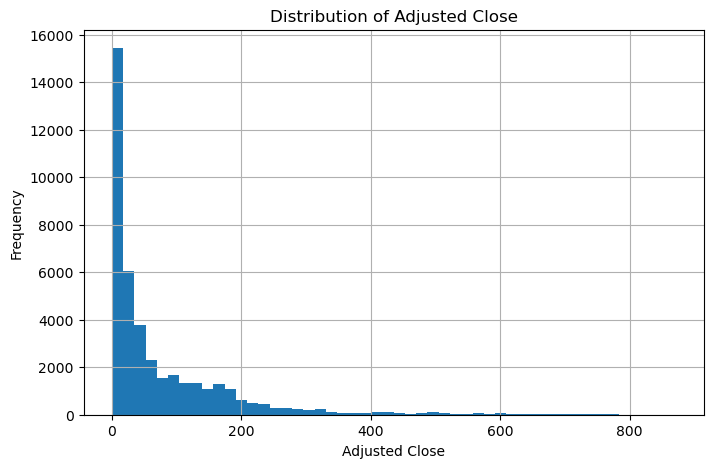

In [28]:
# Price distribution
import matplotlib.pyplot as plt

master["adj_close"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Adjusted Close")
plt.xlabel("Adjusted Close")
plt.ylabel("Frequency")
plt.show()

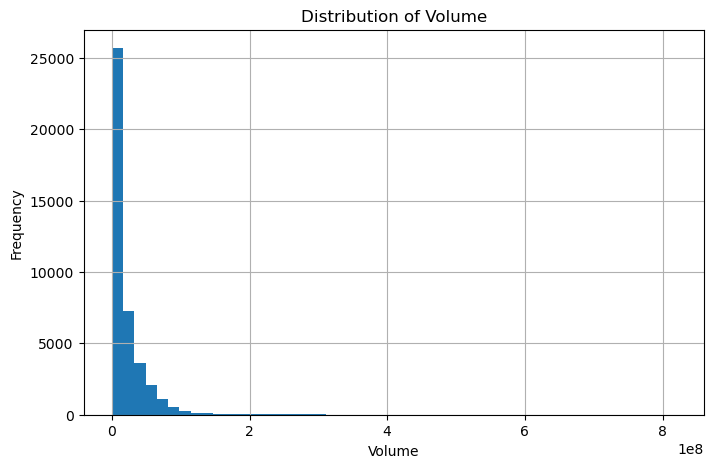

In [29]:
# Volume distribution
master["volume"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

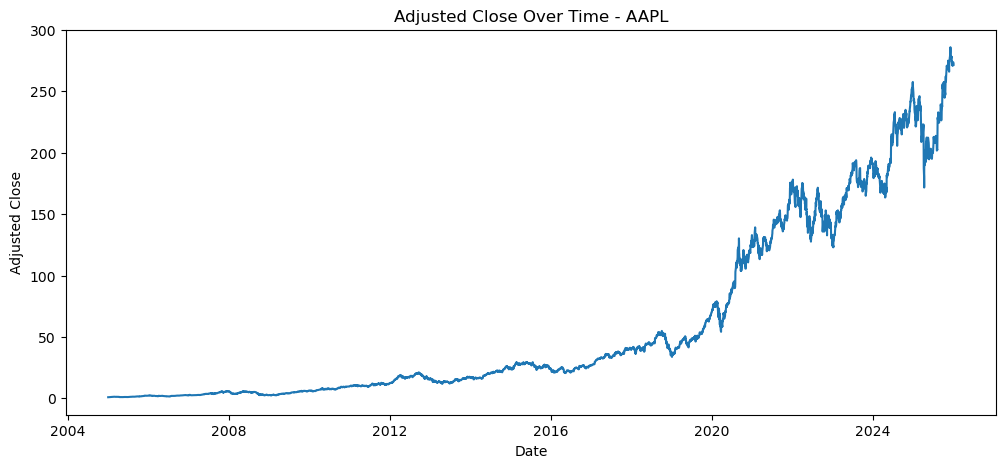

In [30]:
# One ticker price trand example
ticker_example = master[master["symbol"] == master["symbol"].unique()[0]]

plt.figure(figsize=(12,5))
plt.plot(ticker_example["date"], ticker_example["adj_close"])
plt.title(f"Adjusted Close Over Time - {ticker_example['symbol'].iloc[0]}")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.show()

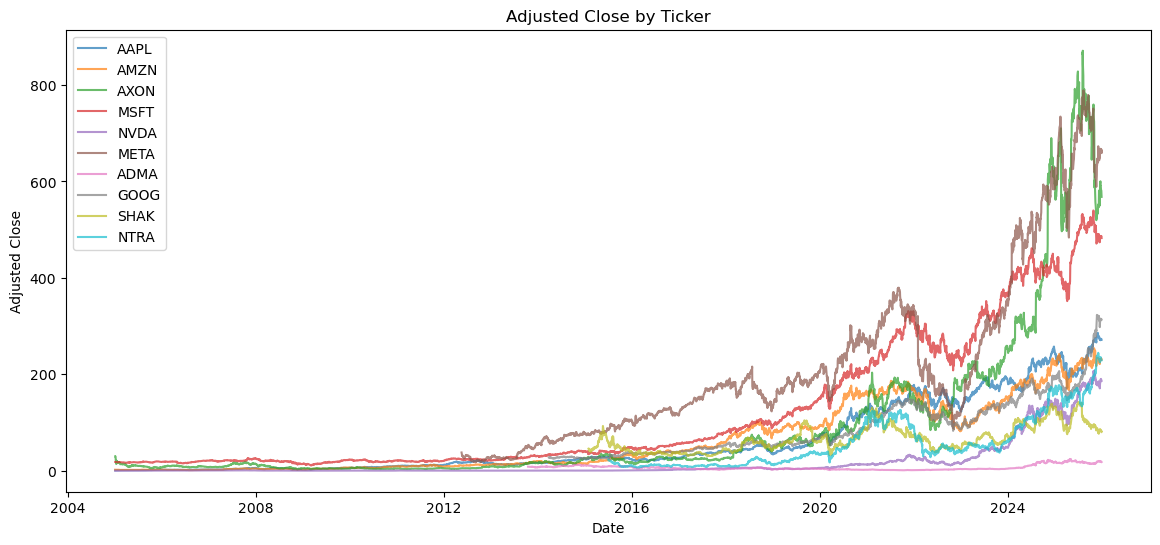

In [31]:
plt.figure(figsize=(14,6))
for sym in master["symbol"].unique():
    temp = master[master["symbol"] == sym]
    plt.plot(temp["date"], temp["adj_close"], label=sym, alpha=0.7)

plt.title("Adjusted Close by Ticker")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

### Feature Engineering on Merged dataset

In [32]:
# Start feature engineering on merged master
master = master.sort_values(["symbol", "date"]).reset_index(drop=True)

master["return_1d"] = master.groupby("symbol")["adj_close"].pct_change()
master["log_return"] = master.groupby("symbol")["adj_close"].transform(
    lambda x: np.log(x / x.shift(1))
)

In [33]:
master[["symbol", "date", "adj_close", "return_1d", "log_return"]].head(10)

,symbol,date,adj_close,return_1d,log_return
0,AAPL,2005-01-03,0.9482,NaN,NaN
1,AAPL,2005-01-04,0.9579,0.0103,0.0102
2,AAPL,2005-01-05,0.9663,0.0088,0.0087
3,AAPL,2005-01-06,0.9670,0.0008,0.0008
4,AAPL,2005-01-07,1.0374,0.0728,0.0703
5,AAPL,2005-01-10,1.0331,-0.0042,-0.0042
6,AAPL,2005-01-11,0.9672,-0.0638,-0.0659
7,AAPL,2005-01-12,0.9807,0.0139,0.0138
8,AAPL,2005-01-13,1.0457,0.0663,0.0642
9,AAPL,2005-01-14,1.0517,0.0057,0.0057


In [34]:
# Momentum features
master["momentum_1m"] = master.groupby("symbol")["adj_close"].pct_change(21)
master["momentum_3m"] = master.groupby("symbol")["adj_close"].pct_change(63)
master["momentum_6m"] = master.groupby("symbol")["adj_close"].pct_change(126)

In [35]:
# Moving averages

master["ma_20"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(20).mean())
master["ma_50"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(50).mean())
master["ma_200"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(200).mean())

master["price_vs_ma50"] = master["adj_close"] / master["ma_50"] - 1
master["price_vs_ma200"] = master["adj_close"] / master["ma_200"] - 1

In [36]:
# Volatility features
master["vol_20"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(20).std() * np.sqrt(252)
)

master["vol_60"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(60).std() * np.sqrt(252)
)

In [37]:
# Parkinson volatility

master["parkinson_daily"] = (np.log(master["high"] / master["low"])) ** 2

master["parkinson_vol_20"] = master.groupby("symbol")["parkinson_daily"].transform(
    lambda x: np.sqrt((1 / (4 * np.log(2))) * x.rolling(20).mean()) * np.sqrt(252)
)

In [40]:
# Intraday range
master["intraday_range"] = (master["high"] - master["low"]) / master["close"]

In [39]:
# Drawdown features
master["rolling_max"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.cummax())
master["drawdown"] = master["adj_close"] / master["rolling_max"] - 1
master["drawdown_regime"] = np.where(master["drawdown"] < -0.20, 1, 0)

In [41]:
# Volume features
master["volume_change"] = master.groupby("symbol")["volume"].pct_change()

master["volume_ma20"] = master.groupby("symbol")["volume"].transform(
    lambda x: x.rolling(20).mean()
)

master["volume_spike"] = master["volume"] / master["volume_ma20"]

In [42]:
# Dividend feature
master["dividend_yield_daily"] = master["dividend"] / master["adj_close"]

### Create simple financial ratios

In [43]:
# Debt and equity features
master["debt_to_equity"] = master["totalLiabilities"] / master["totalShareholderEquity"]
master["asset_to_liability"] = master["totalAssets"] / master["totalLiabilities"]
master["cash_to_assets"] = master["cashAndCashEquivalentsAtCarryingValue"] / master["totalAssets"]

In [44]:
# Per-share / book features

master["book_value_per_share_proxy"] = master["totalShareholderEquity"] / master["commonStockSharesOutstanding"]
master["price_to_book_proxy"] = master["adj_close"] / master["book_value_per_share_proxy"]

In [45]:
# Margin proxies
master["gross_margin"] = master["grossProfit"] / master["totalRevenue"]
master["operating_margin_calc"] = master["operatingIncome"] / master["totalRevenue"]
master["net_margin_calc"] = master["netIncome"] / master["totalRevenue"]

In [46]:
# cashflow ratio
master["operating_cf_to_assets"] = master["operatingCashflow"] / master["totalAssets"]
master["capex_to_assets"] = master["capitalExpenditures"] / master["totalAssets"]


In [47]:
feature_cols_preview = [
    "return_1d", "log_return",
    "momentum_1m", "momentum_3m", "momentum_6m",
    "ma_20", "ma_50", "ma_200",
    "price_vs_ma50", "price_vs_ma200",
    "vol_20", "vol_60", "parkinson_vol_20",
    "intraday_range",
    "drawdown", "drawdown_regime",
    "volume_change", "volume_ma20", "volume_spike",
    "dividend_yield_daily",
    "debt_to_equity", "asset_to_liability", "cash_to_assets",
    "book_value_per_share_proxy", "price_to_book_proxy",
    "gross_margin", "operating_margin_calc", "net_margin_calc",
    "operating_cf_to_assets", "capex_to_assets"
]

master[["symbol", "date"] + feature_cols_preview].head(15)

,symbol,date,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_vol_20,intraday_range,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets
0,AAPL,2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0397,0.0000,0,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2005-01-04,0.0103,0.0102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0391,0.0000,0,0.5850,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2005-01-05,0.0088,0.0087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0186,0.0000,0,-0.3796,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2005-01-06,0.0008,0.0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0245,0.0000,0,0.0369,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2005-01-07,0.0728,0.0703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0705,0.0000,0,2.1570,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AAPL,2005-01-10,-0.0042,-0.0042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0409,-0.0042,0,-0.2254,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AAPL,2005-01-11,-0.0638,-0.0659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0776,-0.0677,0,0.5137,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AAPL,2005-01-12,0.0139,0.0138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0397,-0.0547,0,-0.2649,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AAPL,2005-01-13,0.0663,0.0642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0672,0.0000,0,0.6485,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AAPL,2005-01-14,0.0057,0.0057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0360,0.0000,0,-0.4405,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
### Summary stats for features columns
master[feature_cols_preview].describe().T

/opt/anaconda3/envs/covered_call_ml/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
return_1d,41248.0000,0.0012,0.0283,-0.4561,-0.0113,0.0006,0.0131,0.4067
log_return,41248.0000,0.0008,0.0282,-0.6089,-0.0114,0.0006,0.0130,0.3412
momentum_1m,41048.0000,0.0248,0.1245,-0.5957,-0.0450,0.0218,0.0866,0.9490
momentum_3m,40628.0000,0.0774,0.2286,-0.6771,-0.0607,0.0624,0.1902,1.6306
momentum_6m,39998.0000,0.1634,0.3537,-0.7515,-0.0474,0.1268,0.3086,2.5408
ma_20,41068.0000,77.3107,113.7725,0.1632,7.9764,30.0441,105.6511,787.9905
ma_50,40768.0000,76.7087,112.4878,0.1727,8.0134,29.7723,105.5050,774.8324
ma_200,39268.0000,73.4666,103.7993,0.2046,8.1544,29.9527,104.2646,686.7752
price_vs_ma50,40768.0000,0.0232,0.1077,-0.5779,-0.0358,0.0247,0.0817,0.6177
price_vs_ma200,39268.0000,0.1001,0.2282,-0.6899,-0.0366,0.0974,0.2116,1.4439


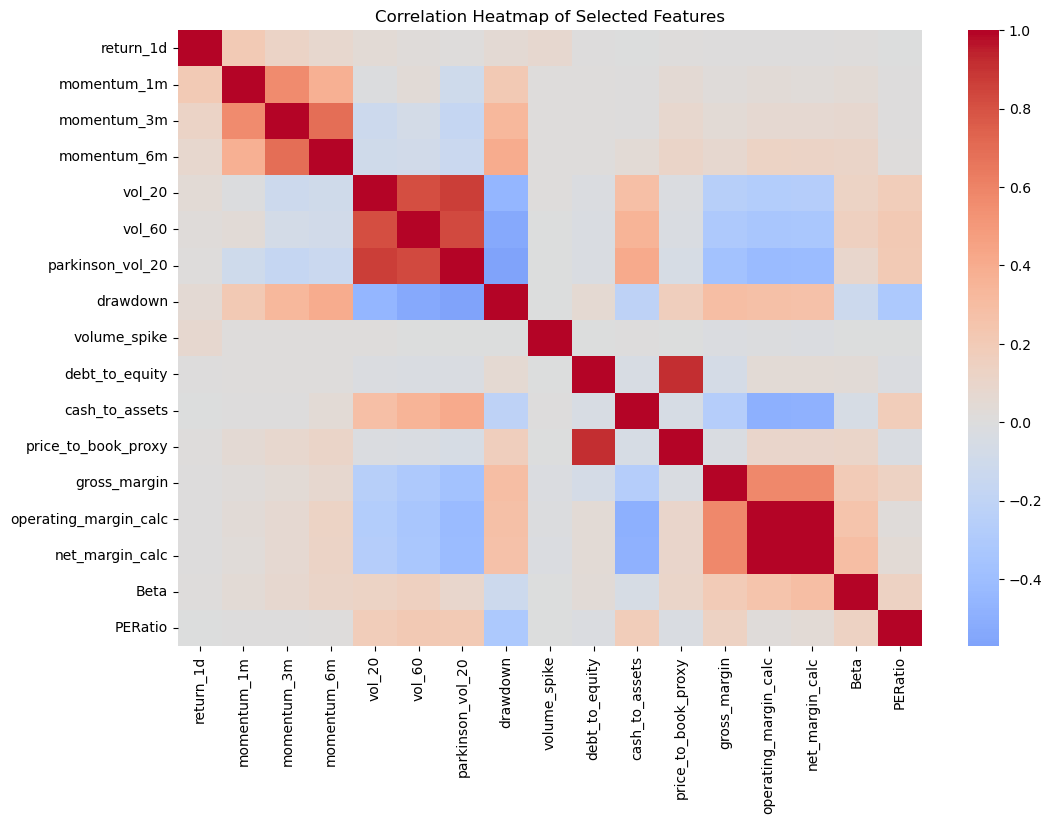

In [49]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "return_1d", "momentum_1m", "momentum_3m", "momentum_6m",
    "vol_20", "vol_60", "parkinson_vol_20",
    "drawdown", "volume_spike",
    "debt_to_equity", "cash_to_assets",
    "price_to_book_proxy", "gross_margin",
    "operating_margin_calc", "net_margin_calc",
    "Beta", "PERatio"
]

corr_df = master[corr_cols].copy()
corr = corr_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

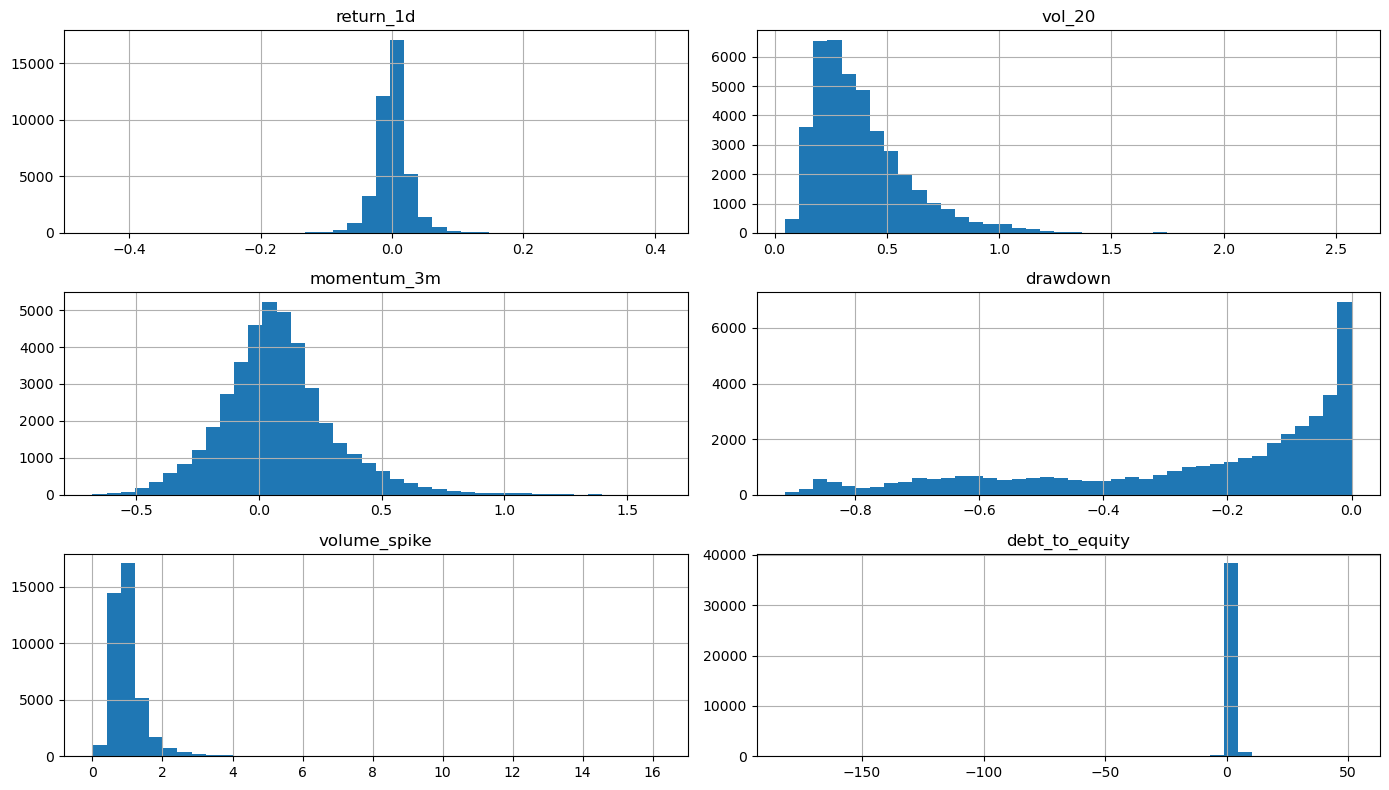

In [50]:
# Histograms of key features
key_hist_cols = ["return_1d", "vol_20", "momentum_3m", "drawdown", "volume_spike", "debt_to_equity"]

master[key_hist_cols].hist(bins=40, figsize=(14,8))
plt.tight_layout()
plt.show()

In [51]:
#handle infinite values cretaed by master
master = master.replace([np.inf, -np.inf], np.nan)

In [52]:
master[feature_cols_preview].isnull().sum().sort_values(ascending=False).head(20)

ma_200                        1990
price_vs_ma200                1990
capex_to_assets               1279
price_to_book_proxy           1279
cash_to_assets                1279
asset_to_liability            1279
debt_to_equity                1279
gross_margin                  1279
operating_margin_calc         1279
net_margin_calc               1279
operating_cf_to_assets        1279
book_value_per_share_proxy    1279
momentum_6m                   1260
momentum_3m                    630
vol_60                         600
price_vs_ma50                  490
ma_50                          490
momentum_1m                    210
vol_20                         200
volume_ma20                    190
dtype: int64

In [53]:
# Drop the null rows existing due to rolling features
master = master.dropna().reset_index(drop=True)

print("Final dataset shape:", master.shape)

Final dataset shape: (38979, 79)


In [54]:
# Saved merged and Engineered dataset
OUT_FEATURE_PATH = BASE / "master_price_fundamentals_features.parquet"
master.to_parquet(OUT_FEATURE_PATH, index=False)

print("Saved:", OUT_FEATURE_PATH)

Saved: ../data/clean/master_price_fundamentals_features.parquet


### prepare the option dataset

In [55]:
# =========================
# STEP 1: PREPARE OPTIONS
# =========================

options["trade_date"] = pd.to_datetime(options["trade_date"])
options["expiration"] = pd.to_datetime(options["expiration"])

# keep only call options
calls = options[options["call_put"].str.lower() == "call"].copy()

print("Calls shape:", calls.shape)
calls.head()

Calls shape: (1063541, 20)


,contractID,symbol,expiration,strike,call_put,last,mark,bid,bid_size,ask,ask_size,volume,open_interest,trade_date,implied_vol,delta,gamma,theta,vega,rho
0,ADMA180817C00002500,ADMA,2018-08-17,2.5000,call,0.0000,3.9500,2.6000,5,5.3000,5,0,0,2018-08-01,2.7465,0.9728,0.0170,-0.0073,0.0008,0.0010
2,ADMA180817C00005000,ADMA,2018-08-17,5.0000,call,0.7500,1.2000,0.2000,50,2.2000,2,0,10,2018-08-01,0.0149,1.0000,0.0000,-0.0003,0.0000,0.0022
4,ADMA180817C00007500,ADMA,2018-08-17,7.5000,call,0.1300,0.0100,0.0000,0,1.0000,15,0,41,2018-08-01,0.4344,0.0456,0.1646,-0.0018,0.0013,0.0001
6,ADMA180921C00002500,ADMA,2018-09-21,2.5000,call,0.0000,3.9200,2.5500,5,5.3000,5,0,0,2018-08-01,1.2344,0.9885,0.0102,-0.0010,0.0007,0.0034
8,ADMA180921C00005000,ADMA,2018-09-21,5.0000,call,1.2500,1.3500,0.3500,66,2.3500,5,0,74,2018-08-01,0.0149,1.0000,0.0000,-0.0003,0.0000,0.0070


In [56]:
# Merge daily stock prices into options
price_lookup = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "trade_date", "adj_close": "stock_price"}
)

calls = calls.merge(
    price_lookup,
    on=["symbol", "trade_date"],
    how="inner"
)

print("Calls after merging stock price:", calls.shape)
calls.head()

Calls after merging stock price: (1020573, 21)


,contractID,symbol,expiration,strike,call_put,last,mark,bid,bid_size,ask,ask_size,volume,open_interest,trade_date,implied_vol,delta,gamma,theta,vega,rho,stock_price
0,ADMA180817C00002500,ADMA,2018-08-17,2.5000,call,0.0000,3.9500,2.6000,5,5.3000,5,0,0,2018-08-01,2.7465,0.9728,0.0170,-0.0073,0.0008,0.0010,6.4000
1,ADMA180817C00005000,ADMA,2018-08-17,5.0000,call,0.7500,1.2000,0.2000,50,2.2000,2,0,10,2018-08-01,0.0149,1.0000,0.0000,-0.0003,0.0000,0.0022,6.4000
2,ADMA180817C00007500,ADMA,2018-08-17,7.5000,call,0.1300,0.0100,0.0000,0,1.0000,15,0,41,2018-08-01,0.4344,0.0456,0.1646,-0.0018,0.0013,0.0001,6.4000
3,ADMA180921C00002500,ADMA,2018-09-21,2.5000,call,0.0000,3.9200,2.5500,5,5.3000,5,0,0,2018-08-01,1.2344,0.9885,0.0102,-0.0010,0.0007,0.0034,6.4000
4,ADMA180921C00005000,ADMA,2018-09-21,5.0000,call,1.2500,1.3500,0.3500,66,2.3500,5,0,74,2018-08-01,0.0149,1.0000,0.0000,-0.0003,0.0000,0.0070,6.4000


In [57]:
# compute dte


calls["dte"] = (calls["expiration"] - calls["trade_date"]).dt.days
calls = calls[calls["dte"] > 0].copy()

print(calls["dte"].describe())

count   1007970.0000
mean        175.0804
std         214.8408
min           1.0000
25%          23.0000
50%          78.0000
75%         233.0000
max        1052.0000
Name: dte, dtype: float64


In [59]:
# Filter to reasnable delta range


calls_filtered = calls[(calls["delta"] >= 0.10) & (calls["delta"] <= 0.70)].copy()

print(f"Contracts in delta range 0.10-0.70: {len(calls_filtered):,}")
print(calls_filtered["delta"].describe())

Contracts in delta range 0.10-0.70: 301,961
count   301961.0000
mean         0.3943
std          0.1796
min          0.1000
25%          0.2329
50%          0.3933
75%          0.5539
max          0.7000
Name: delta, dtype: float64


In [65]:

# ASSIGN MONEyness BUCKET


def assign_moneyness_bucket(delta):
    if 0.10 <= delta < 0.28:
        return "OTM10"
    elif 0.29 <= delta < 0.50:
        return "OTM5"
    elif 0.51 <= delta <= 0.70:
        return "ATM"
    else:
        return "OUT_OF_RANGE"

calls_filtered["moneyness_bucket"] = calls_filtered["delta"].apply(assign_moneyness_bucket)

print(calls_filtered["moneyness_bucket"].value_counts(dropna=False))

calls_filtered = calls_filtered[
    calls_filtered["moneyness_bucket"] != "OUT_OF_RANGE"
].copy()

moneyness_bucket
OTM10    93621
OTM5     92533
ATM      82031
Name: count, dtype: int64


In [73]:
# assign DTE bucket

def assign_dte_bucket(dte):
    if 7 <= dte <= 30:
        return "30"
    elif 31 <= dte <= 45:
        return "60"
    elif 46 <= dte <= 120:
        return "90"
    else:
        return "OUT_OF_RANGE"

calls_filtered["dte_bucket"] = calls_filtered["dte"].apply(assign_dte_bucket)

print(calls_filtered["dte_bucket"].value_counts(dropna=False))

calls_filtered = calls_filtered[
    calls_filtered["dte_bucket"] != "OUT_OF_RANGE"
].copy()

dte_bucket
30    44607
90    38718
60    30175
Name: count, dtype: int64


In [74]:
# Build final contract bucket label
calls_filtered["bucket_label"] = (
    calls_filtered["moneyness_bucket"] + "_" + calls_filtered["dte_bucket"]
)

print(calls_filtered["bucket_label"].value_counts())
calls_filtered[["symbol", "trade_date", "delta", "dte", "bucket_label"]].head()

bucket_label
OTM10_30    17050
OTM10_90    14983
OTM5_30     14710
ATM_30      12847
OTM5_90     12588
ATM_90      11147
OTM5_60     10607
OTM10_60    10037
ATM_60       9531
Name: count, dtype: int64


,symbol,trade_date,delta,dte,bucket_label
14,ADMA,2018-10-01,0.1404,18,OTM10_30
36,ADMA,2018-11-01,0.4863,106,OTM5_90
44,ADMA,2018-12-03,0.2430,18,OTM10_30
51,ADMA,2018-12-03,0.6319,74,ATM_90
61,ADMA,2019-02-01,0.6930,42,ATM_60


In [75]:
# compute premium


calls_filtered["premium"] = (calls_filtered["bid"] + calls_filtered["ask"]) / 2

calls_filtered[["bid", "ask", "premium"]].head()

,bid,ask,premium
14,0.0500,0.1000,0.0750
36,0.1000,2.0000,1.0500
44,0.1500,0.3500,0.2500
51,0.6000,1.3000,0.9500
61,0.5500,0.7000,0.6250


In [58]:
# clean numeric options

numeric_cols = [
    "strike", "bid", "ask", "last", "volume", "open_interest",
    "implied_vol", "delta", "gamma", "theta", "vega", "rho"
]

for col in numeric_cols:
    if col in calls.columns:
        calls[col] = pd.to_numeric(calls[col], errors="coerce")

In [76]:
# get future stock price at expiration

future_prices = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "expiration", "adj_close": "future_price"}
)

calls_filtered = calls_filtered.merge(
    future_prices,
    on=["symbol", "expiration"],
    how="left"
)

calls_filtered = calls_filtered.dropna(subset=["future_price"]).copy()

print("After merging future price:", calls_filtered.shape)

After merging future price: (106730, 27)


In [77]:
# Compute covered call payoff and return

calls_filtered["covered_call_payoff"] = (
    calls_filtered["premium"] +
    np.minimum(calls_filtered["future_price"], calls_filtered["strike"]) -
    calls_filtered["stock_price"]
)

calls_filtered["covered_call_return"] = (
    calls_filtered["covered_call_payoff"] / calls_filtered["stock_price"]
)

calls_filtered[[
    "symbol", "trade_date", "bucket_label",
    "stock_price", "strike", "premium", "future_price",
    "covered_call_payoff", "covered_call_return"
]].head()

,symbol,trade_date,bucket_label,stock_price,strike,premium,future_price,covered_call_payoff,covered_call_return
0,ADMA,2018-10-01,OTM10_30,5.8500,7.5000,0.0750,5.5300,-0.2450,-0.0419
1,ADMA,2018-11-01,OTM5_90,5.5300,7.5000,1.0500,4.2200,-0.2600,-0.0470
2,ADMA,2018-12-03,OTM10_30,5.2600,7.5000,0.2500,2.4100,-2.6000,-0.4943
3,ADMA,2018-12-03,ATM_90,5.2600,5.0000,0.9500,4.2200,-0.0900,-0.0171
4,ADMA,2019-02-01,ATM_60,2.8200,2.5000,0.6250,3.9900,0.3050,0.1082


In [78]:

# COMPUTE REALIZED VOLATILITY OVER HOLDING PERIOD


price_lookup = master[["symbol", "date", "return_1d"]].copy()
price_lookup = price_lookup.sort_values(["symbol", "date"]).reset_index(drop=True)

def realized_vol_for_cycle(symbol, start_date, end_date, price_df):
    temp = price_df[
        (price_df["symbol"] == symbol) &
        (price_df["date"] >= start_date) &
        (price_df["date"] <= end_date)
    ].copy()

    if temp["return_1d"].dropna().shape[0] < 2:
        return np.nan

    return temp["return_1d"].std() * np.sqrt(252)

calls_filtered["realized_vol_cycle"] = calls_filtered.apply(
    lambda r: realized_vol_for_cycle(
        r["symbol"],
        r["trade_date"],
        r["expiration"],
        price_lookup
    ),
    axis=1
)

calls_filtered[[
    "symbol", "trade_date", "expiration",
    "covered_call_return", "realized_vol_cycle"
]].head()

,symbol,trade_date,expiration,covered_call_return,realized_vol_cycle
0,ADMA,2018-10-01,2018-10-19,-0.0419,0.5093
1,ADMA,2018-11-01,2019-02-15,-0.0470,1.1838
2,ADMA,2018-12-03,2018-12-21,-0.4943,2.0405
3,ADMA,2018-12-03,2019-02-15,-0.0171,1.3807
4,ADMA,2019-02-01,2019-03-15,0.1082,0.8782


In [79]:
# Compute risk-free cycle return and Sharpe proxy

RISK_FREE = 0.05

calls_filtered["rf_cycle"] = (
    (1 + RISK_FREE) ** (calls_filtered["dte"] / 252) - 1
)

calls_filtered["sharpe_proxy"] = (
    (calls_filtered["covered_call_return"] - calls_filtered["rf_cycle"]) /
    calls_filtered["realized_vol_cycle"]
)

calls_filtered = calls_filtered.replace([np.inf, -np.inf], np.nan)

calls_filtered[[
    "symbol", "bucket_label", "covered_call_return",
    "realized_vol_cycle", "rf_cycle", "sharpe_proxy"
]].head()

,symbol,bucket_label,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,ADMA,OTM10_30,-0.0419,0.5093,0.0035,-0.0891
1,ADMA,OTM5_90,-0.0470,1.1838,0.0207,-0.0572
2,ADMA,OTM10_30,-0.4943,2.0405,0.0035,-0.2440
3,ADMA,ATM_90,-0.0171,1.3807,0.0144,-0.0228
4,ADMA,ATM_60,0.1082,0.8782,0.0082,0.1139


In [80]:
# Aggregate sharpe to bucket level


bucket_perf = (
    calls_filtered
    .dropna(subset=["sharpe_proxy"])
    .groupby(["symbol", "trade_date", "bucket_label"], as_index=False)
    .agg({
        "covered_call_return": "mean",
        "realized_vol_cycle": "mean",
        "rf_cycle": "mean",
        "sharpe_proxy": "mean"
    })
)

print(bucket_perf.shape)
bucket_perf.head()

(8102, 7)


,symbol,trade_date,bucket_label,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM10_30,0.2900,0.2948,0.0016,0.9783
1,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
2,AAPL,2010-10-01,ATM_30,0.7320,0.2868,0.0014,2.5474
3,AAPL,2010-10-01,OTM10_30,0.2145,0.2868,0.0014,0.7433
4,AAPL,2011-04-01,ATM_30,0.6529,0.0709,0.0014,9.1882


In [81]:
# create label df

label_df = (
    bucket_perf
    .sort_values(
        ["symbol", "trade_date", "sharpe_proxy"],
        ascending=[True, True, False]
    )
    .groupby(["symbol", "trade_date"], as_index=False)
    .first()
)

label_df = label_df.rename(
    columns={
        "trade_date": "date",
        "bucket_label": "optimal_bucket"
    }
)

print(label_df.shape)
print(label_df["optimal_bucket"].value_counts())
label_df.head()

(1087, 7)
optimal_bucket
ATM_90      400
OTM10_90    201
ATM_30      136
OTM5_90     111
ATM_60      105
OTM10_60     43
OTM10_30     39
OTM5_30      34
OTM5_60      18
Name: count, dtype: int64


,symbol,date,optimal_bucket,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
1,AAPL,2010-10-01,ATM_30,0.7320,0.2868,0.0014,2.5474
2,AAPL,2011-04-01,ATM_30,0.6529,0.0709,0.0014,9.1882
3,AAPL,2011-07-01,ATM_30,0.5414,0.1107,0.0014,4.8787
4,AAPL,2011-09-01,ATM_30,0.7315,0.2277,0.0016,3.2059


In [87]:
# Merge label df into master

# Merge label_df into master using LEFT JOIN
final_dataset = master.merge(
    label_df[["symbol", "date", "optimal_bucket"]],
    on=["symbol", "date"],
    how="left"
)

# Sort before fill
final_dataset = final_dataset.sort_values(["symbol", "date"]).reset_index(drop=True)

# Forward fill + backward fill within each symbol
final_dataset["optimal_bucket"] = (
    final_dataset.groupby("symbol")["optimal_bucket"]
    .transform(lambda x: x.ffill().bfill())
)

print("Final dataset shape:", final_dataset.shape)
print("Duplicate symbol-date rows:",
      final_dataset.duplicated(subset=["symbol", "date"]).sum())

print("Remaining missing optimal_bucket values:",
      final_dataset["optimal_bucket"].isna().sum())

final_dataset.tail()

Final dataset shape: (38979, 80)
Duplicate symbol-date rows: 0
Remaining missing optimal_bucket values: 0


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_daily,parkinson_vol_20,intraday_range,rolling_max,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets,optimal_bucket
38974,2025-12-24,SHAK,84.9800,85.5600,84.2409,85.1100,85.1100,501336,0.0000,1.0000,2025-09-30,367411000.0000,175917000.0000,18548000.0000,157369000.0000,21651000.0000,49240000.0000,1827185000.0000,414777000.0000,357757000.0000,1291948000.0000,225350000.0000,247469000.0000,509015000.0000,41874000.0000,62999000.0000,39259000.0000,-39259000.0000,-2790000.0000,271000.0000,12501000.0000,3710833000,79.7400,13.0500,0.0000,1.0900,1445306000,0.0316,0.0513,0.0236,0.0949,1.7660,144.6500,72.9300,92.6700,102.9100,40257700,0.0019,0.0019,-0.0172,-0.0966,-0.3851,82.9000,87.7736,103.3967,-0.0303,-0.1769,0.3923,0.4015,0.0002,0.3844,0.0155,142.0300,-0.4008,1,-0.6650,1766565.7500,0.2838,0.0000,2.5381,1.4143,0.1958,12.1559,7.0016,0.4788,0.0505,0.0340,0.0345,0.0215,ATM_30
38975,2025-12-26,SHAK,84.5700,85.0600,83.4500,83.7600,83.7600,916333,0.0000,1.0000,2025-09-30,367411000.0000,175917000.0000,18548000.0000,157369000.0000,21651000.0000,49240000.0000,1827185000.0000,414777000.0000,357757000.0000,1291948000.0000,225350000.0000,247469000.0000,509015000.0000,41874000.0000,62999000.0000,39259000.0000,-39259000.0000,-2790000.0000,271000.0000,12501000.0000,3710833000,79.7400,13.0500,0.0000,1.0900,1445306000,0.0316,0.0513,0.0236,0.0949,1.7660,144.6500,72.9300,92.6700,102.9100,40257700,-0.0159,-0.0160,-0.0371,-0.0935,-0.3951,82.6640,87.6060,103.3795,-0.0439,-0.1898,0.3898,0.4005,0.0004,0.3790,0.0192,142.0300,-0.4103,1,0.8278,1733619.6500,0.5286,0.0000,2.5381,1.4143,0.1958,12.1559,6.8905,0.4788,0.0505,0.0340,0.0345,0.0215,ATM_30
38976,2025-12-29,SHAK,82.9000,83.5300,80.4800,81.9200,81.9200,1353914,0.0000,1.0000,2025-09-30,367411000.0000,175917000.0000,18548000.0000,157369000.0000,21651000.0000,49240000.0000,1827185000.0000,414777000.0000,357757000.0000,1291948000.0000,225350000.0000,247469000.0000,509015000.0000,41874000.0000,62999000.0000,39259000.0000,-39259000.0000,-2790000.0000,271000.0000,12501000.0000,3710833000,79.7400,13.0500,0.0000,1.0900,1445306000,0.0316,0.0513,0.0236,0.0949,1.7660,144.6500,72.9300,92.6700,102.9100,40257700,-0.0220,-0.0222,-0.0741,-0.1341,-0.4174,82.3860,87.3792,103.3753,-0.0625,-0.2075,0.3948,0.3966,0.0014,0.3837,0.0372,142.0300,-0.4232,1,0.4775,1770354.5500,0.7648,0.0000,2.5381,1.4143,0.1958,12.1559,6.7391,0.4788,0.0505,0.0340,0.0345,0.0215,ATM_30
38977,2025-12-30,SHAK,81.8200,82.2000,79.5500,79.9500,79.9500,2040616,0.0000,1.0000,2025-09-30,367411000.0000,175917000.0000,18548000.0000,157369000.0000,21651000.0000,49240000.0000,1827185000.0000,414777000.0000,357757000.0000,1291948000.0000,225350000.0000,247469000.0000,509015000.0000,41874000.0000,62999000.0000,39259000.0000,-39259000.0000,-2790000.0000,271000.0000,12501000.0000,3710833000,79.7400,13.0500,0.0000,1.0900,1445306000,0.0316,0.0513,0.0236,0.0949,1.7660,144.6500,72.9300,92.6700,102.9100,40257700,-0.0240,-0.0243,-0.0861,-0.1459,-0.4222,82.0775,87.1344,103.3376,-0.0825

In [86]:

# SAVE FINAL MODELING FILE

FINAL_MODEL_PATH = BASE / "daily_stock_optimal_bucket_modeling.parquet"
final_dataset.to_parquet(FINAL_MODEL_PATH, index=False)

print("Saved final modeling dataset:", FINAL_MODEL_PATH)

Saved final modeling dataset: ../data/clean/daily_stock_optimal_bucket_modeling.parquet


In [88]:
symbol_stats = (
    final_dataset.groupby("symbol")["date"]
    .agg(["min","max","count"])
)

print(symbol_stats)

              min        max  count
symbol                             
AAPL   2006-01-03 2025-12-31   5031
ADMA   2014-08-04 2025-12-31   2866
AMZN   2006-01-03 2025-12-31   5031
AXON   2006-01-03 2025-12-31   5031
GOOG   2015-01-09 2025-12-31   2761
META   2013-03-07 2025-12-31   3226
MSFT   2006-01-03 2025-12-31   5031
NTRA   2016-04-18 2025-12-31   2442
NVDA   2006-01-31 2025-12-31   5012
SHAK   2015-11-12 2025-12-31   2548


In [89]:
bucket_counts = final_dataset["optimal_bucket"].value_counts()

print(bucket_counts)

optimal_bucket
ATM_90      11825
ATM_30       6991
OTM10_90     5584
OTM10_30     3369
OTM5_60      2787
OTM5_90      2763
ATM_60       2603
OTM5_30      2096
OTM10_60      961
Name: count, dtype: int64


In [90]:
bucket_pct = final_dataset["optimal_bucket"].value_counts(normalize=True)

print(bucket_pct.round(3))

optimal_bucket
ATM_90     0.3030
ATM_30     0.1790
OTM10_90   0.1430
OTM10_30   0.0860
OTM5_60    0.0720
OTM5_90    0.0710
ATM_60     0.0670
OTM5_30    0.0540
OTM10_60   0.0250
Name: proportion, dtype: float64


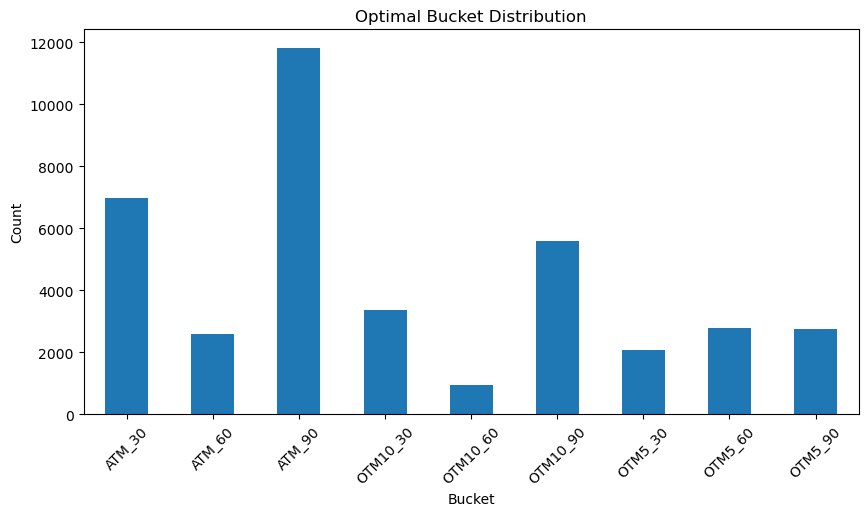

In [91]:
import matplotlib.pyplot as plt

final_dataset["optimal_bucket"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Optimal Bucket Distribution")
plt.xlabel("Bucket")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [94]:
# knowing important features from the final dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df = final_dataset.copy()

# Encode target
le = LabelEncoder()
df["optimal_bucket_encoded"] = le.fit_transform(df["optimal_bucket"])

# Drop non-feature columns
drop_cols = [
    "symbol",
    "date",
    "fiscalDateEnding",   # datetime column causing the issue
    "optimal_bucket",
    "optimal_bucket_encoded"
]

# keep only remaining columns
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["optimal_bucket_encoded"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (38979, 76)
Target shape: (38979,)


In [95]:
# extra safety: keep only numeric columns
X = X.select_dtypes(include=["number"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNon-numeric columns still in X:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X, y)
print("Random Forest fitted successfully.")

X shape: (38979, 76)
y shape: (38979,)

Non-numeric columns still in X:
[]
Random Forest fitted successfully.


rolling_max                             0.0447
ma_200                                  0.0373
gross_margin                            0.0356
ma_50                                   0.0310
book_value_per_share_proxy              0.0302
ma_20                                   0.0294
asset_to_liability                      0.0284
commonStockSharesOutstanding            0.0284
totalLiabilities                        0.0281
longTermDebt                            0.0275
high                                    0.0258
low                                     0.0256
close                                   0.0252
totalAssets                             0.0251
open                                    0.0234
52WeekLow                               0.0220
EPS                                     0.0215
adj_close                               0.0202
totalShareholderEquity                  0.0196
totalCurrentAssets                      0.0194
200DayMovingAverage                     0.0187
operatingExpe

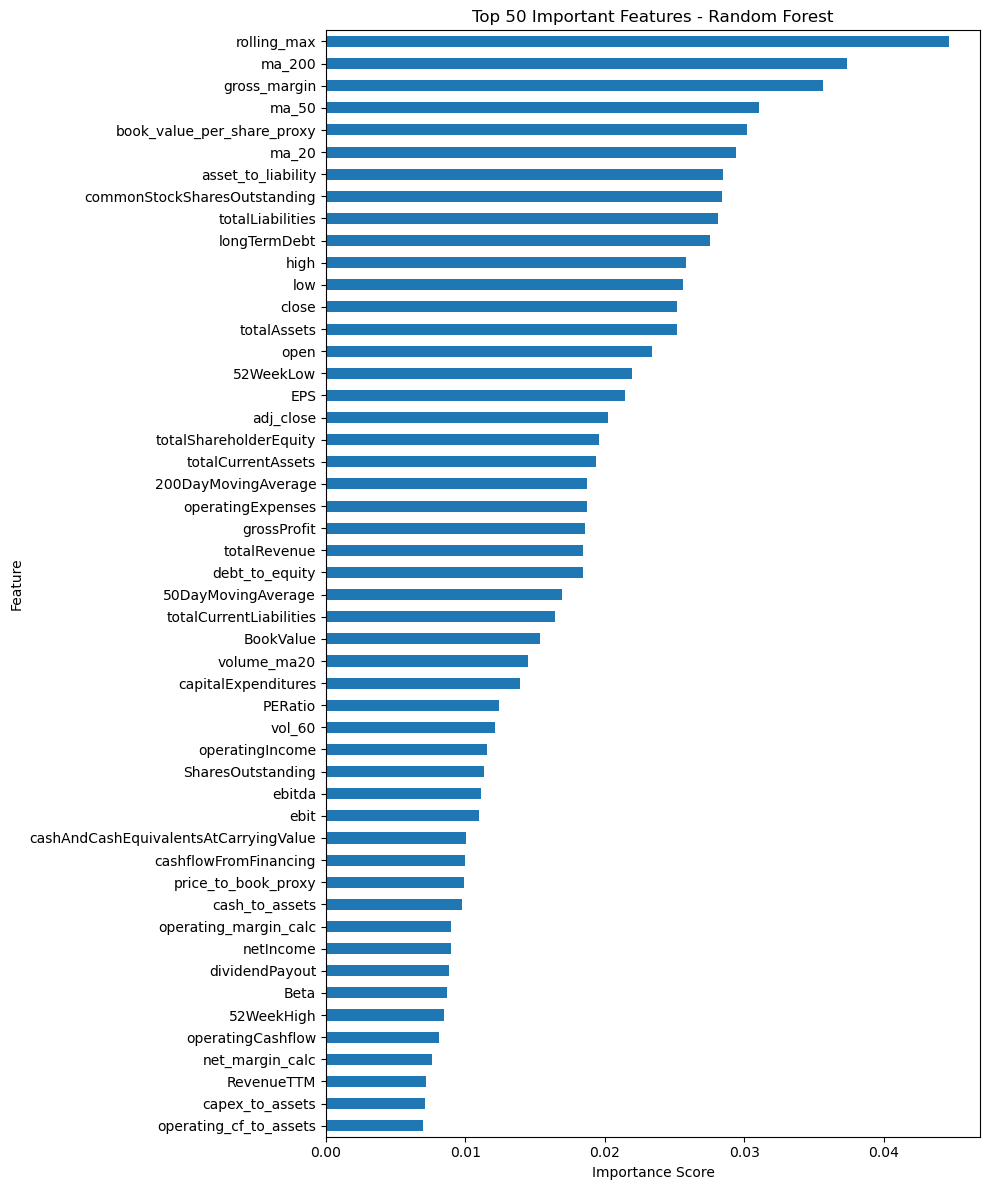

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_50_features = feature_importance.head(50)

print(top_50_features)

plt.figure(figsize=(10, 12))
top_50_features.sort_values().plot(kind="barh")
plt.title("Top 50 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [97]:
print(df.select_dtypes(exclude=["number"]).columns.tolist())

['date', 'symbol', 'fiscalDateEnding', 'optimal_bucket']
